<a href="https://colab.research.google.com/github/Vino8801/AI-Job-Replacement/blob/main/AI_Job_replacement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AI job replacement.csv')
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

In [ ]:
df.isnull().sum()

,0
job_id,0
job_role,0
industry,0
country,0
year,0
automation_risk_percent,0
ai_replacement_score,0
skill_gap_index,0
salary_before_usd,0
salary_after_usd,0


In [ ]:
categorical_cols = ['job_role','industry','country','education_requirement_level','automation_risk_category']
for col in categorical_cols:
  print(f"\n{col.upper()} - unique values:{df[col].nunique()}")
  print(df[col].value_counts() .head())




JOB_ROLE - unique values:10
job_role
Marketing Specialist    1551
Teacher                 1550
Data Analyst            1531
Mechanical Engineer     1526
Customer Support Rep    1512
Name: count, dtype: int64

INDUSTRY - unique values:8
industry
Finance           1942
Transportation    1902
Technology        1899
Energy            1880
Healthcare        1876
Name: count, dtype: int64

COUNTRY - unique values:9
country
Singapore    1748
USA          1731
UK           1716
Brazil       1659
Australia    1642
Name: count, dtype: int64

EDUCATION_REQUIREMENT_LEVEL - unique values:5
education_requirement_level
4    3070
2    3027
3    3023
5    2987
1    2893
Name: count, dtype: int64

AUTOMATION_RISK_CATEGORY - unique values:3
automation_risk_category
Medium    6464
High      4496
Low       4040
Name: count, dtype: int64


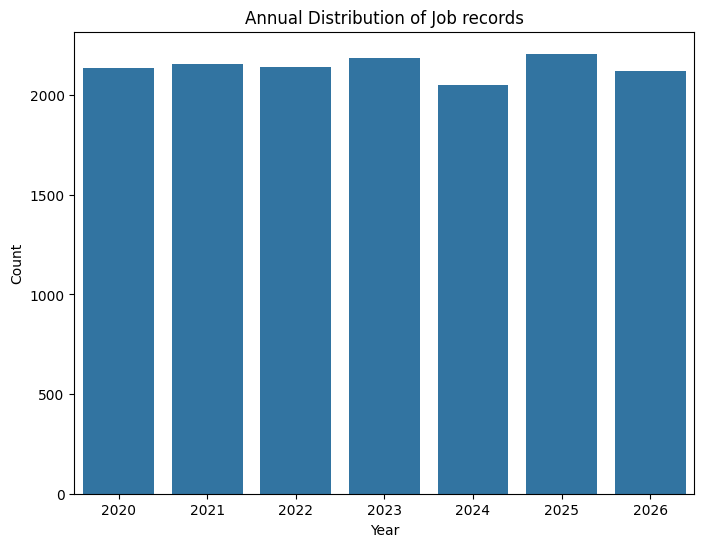

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

year_distribution = df['year'].value_counts().sort_index()
plt.figure(figsize=(8,6))
sns.barplot(x=year_distribution.index, y=year_distribution.values)
plt.title('Annual Distribution of Job records')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()



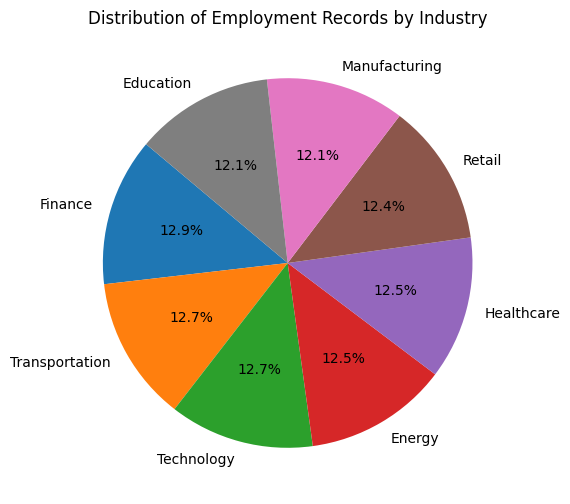

In [ ]:
industry_counts= df['industry'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(industry_counts,labels=industry_counts.index,autopct='%1.1f%%',startangle=140)
plt.title('Distribution of Employment Records by Industry')
plt.show()

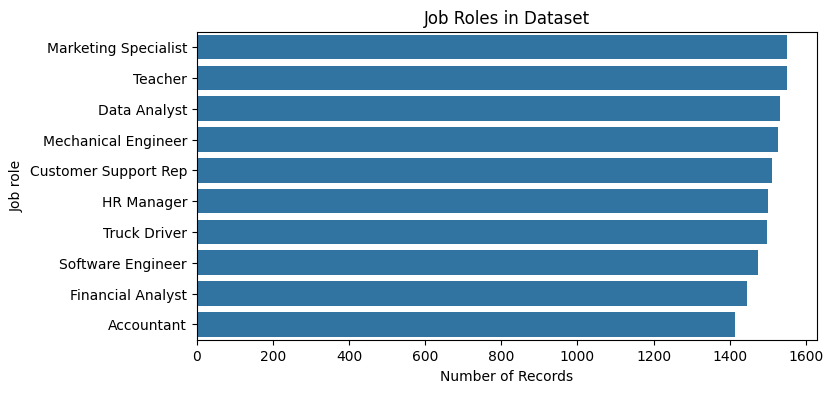

In [ ]:
job_roles= df['job_role'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=job_roles.values, y=job_roles.index)
plt.title('Job Roles in Dataset')
plt.xlabel('Number of Records')
plt.ylabel('Job role')
plt.show()

**OBJECTIVE 1**

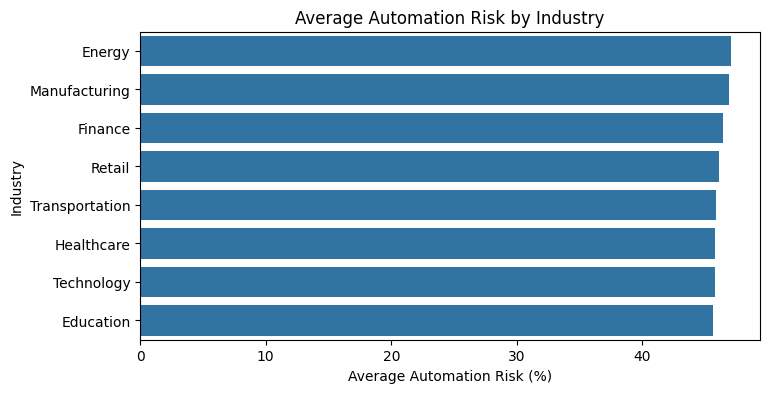

In [ ]:
industry_risk = df.groupby('industry')['automation_risk_percent'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=industry_risk.values,y=industry_risk.index)
plt.title('Average Automation Risk by Industry')
plt.xlabel('Average Automation Risk (%)')
plt.ylabel('Industry')
plt.show()

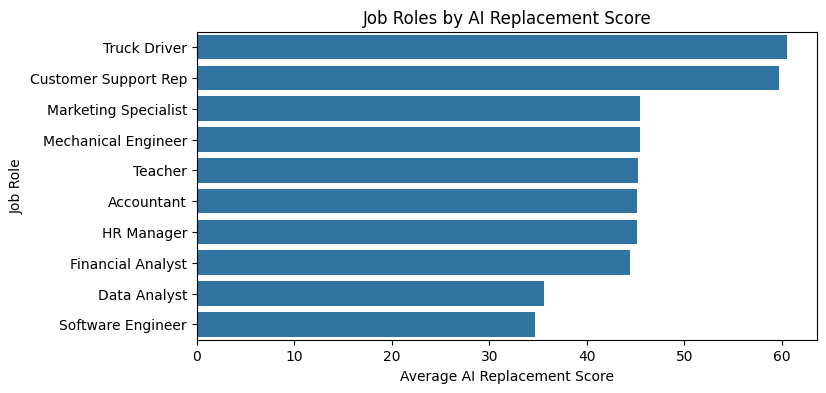

In [ ]:
role_ai = df.groupby('job_role')['ai_replacement_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=role_ai.values,y=role_ai.index)
plt.title('Job Roles by AI Replacement Score')
plt.xlabel('Average AI Replacement Score')
plt.ylabel('Job Role')
plt.show()

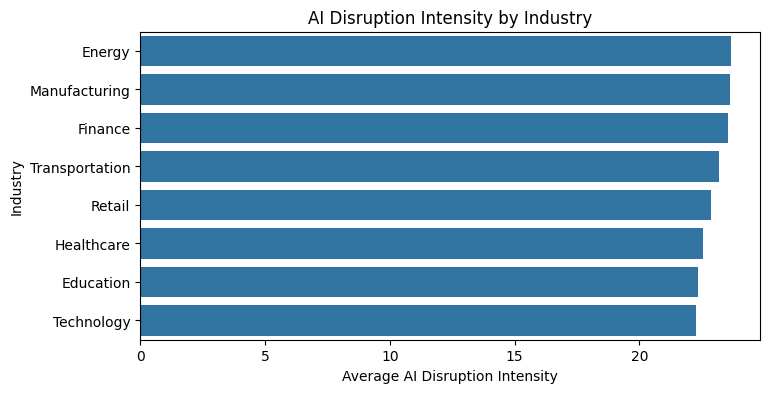

In [ ]:
industry_disruption = df.groupby('industry')['ai_disruption_intensity'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=industry_disruption.values, y=industry_disruption.index)
plt.title('AI Disruption Intensity by Industry')
plt.xlabel('Average AI Disruption Intensity')
plt.ylabel('Industry')
plt.show()



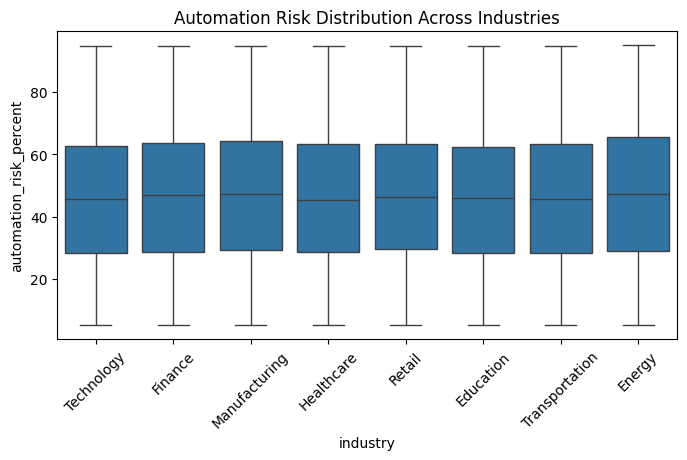

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x='industry',y='automation_risk_percent')
plt.title('Automation Risk Distribution Across Industries')
plt.xticks(rotation=45)
plt.show()

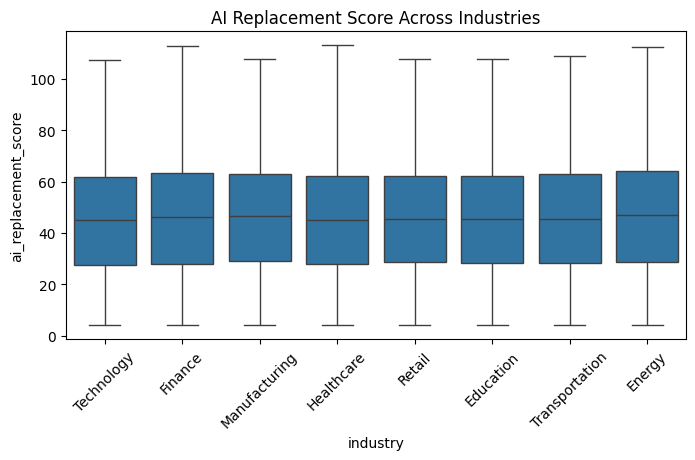

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x='industry',y='ai_replacement_score')
plt.title('AI Replacement Score Across Industries')
plt.xticks(rotation=45)
plt.show()

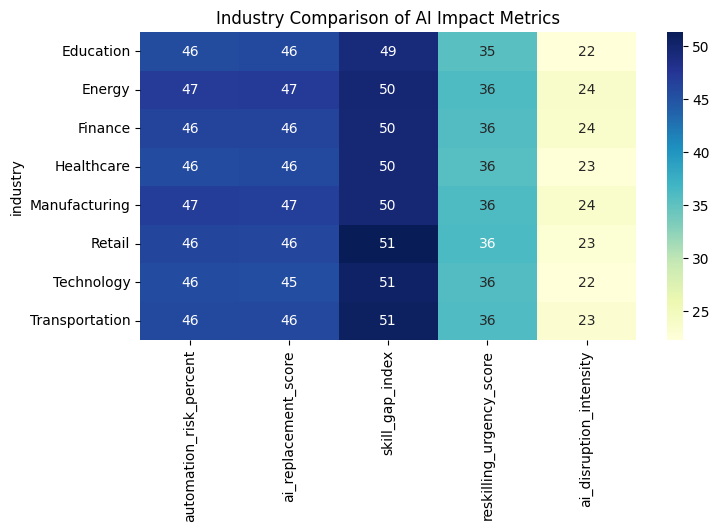

In [ ]:
industry_metrics= df.groupby('industry')[['automation_risk_percent','ai_replacement_score','skill_gap_index','reskilling_urgency_score','ai_disruption_intensity']].mean()
plt.figure(figsize=(8,4))
sns.heatmap(industry_metrics,annot=True,cmap='YlGnBu')
plt.title('Industry Comparison of AI Impact Metrics')
plt.show()


**objective 2**

In [ ]:
salary_comparison = df[['salary_before_usd','salary_after_usd']].describe()
salary_comparison

,salary_before_usd,salary_after_usd
count,15000.000000,15000.000000
mean,89771.375196,89870.633937
std,34522.125434,35897.592992
min,30003.690000,19022.670000
25%,60127.225000,59223.457500
50%,89533.050000,88787.330000
75%,119823.840000,118432.967500
max,149984.060000,191961.210000


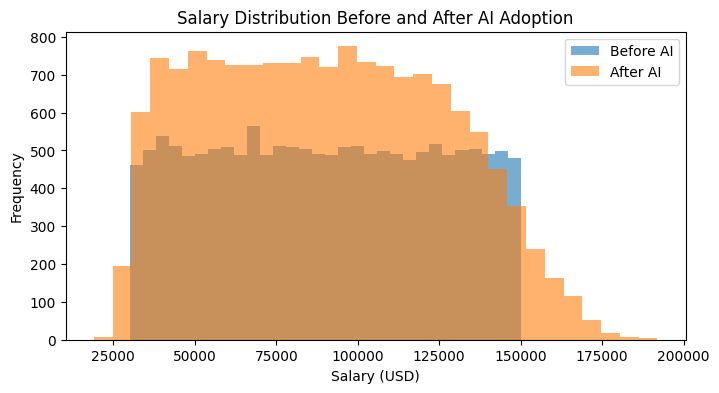

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df['salary_before_usd'],bins=30,alpha=0.6,label='Before AI')
plt.hist(df['salary_after_usd'],bins=30,alpha=0.6,label='After AI')
plt.title('Salary Distribution Before and After AI Adoption')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

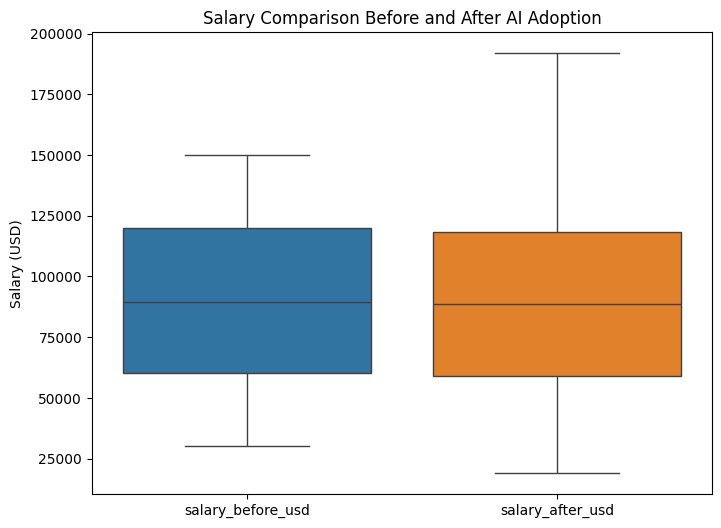

In [ ]:
salary_data = df[['salary_before_usd','salary_after_usd']]
plt.figure(figsize=(8,6))
sns.boxplot(data=salary_data)
plt.title('Salary Comparison Before and After AI Adoption')
plt.ylabel('Salary (USD)')
plt.show()

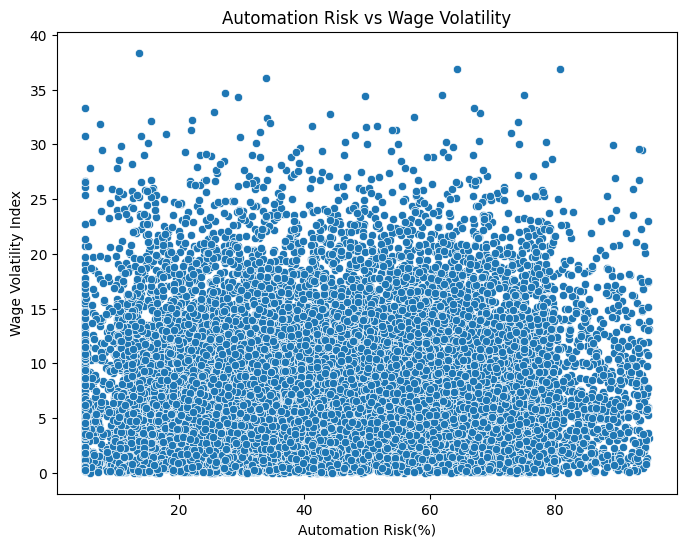

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='automation_risk_percent', y='wage_volatility_index')
plt.title('Automation Risk vs Wage Volatility')
plt.xlabel('Automation Risk(%)')
plt.ylabel('Wage Volatility Index')
plt.show()

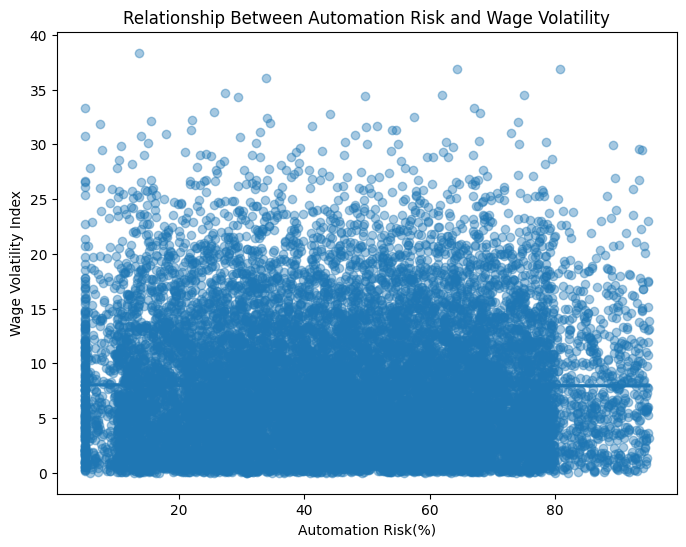

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,x='automation_risk_percent',y='wage_volatility_index',scatter_kws={'alpha':0.4})
plt.title('Relationship Between Automation Risk and Wage Volatility')
plt.xlabel('Automation Risk(%)')
plt.ylabel('Wage Volatility Index')
plt.show()

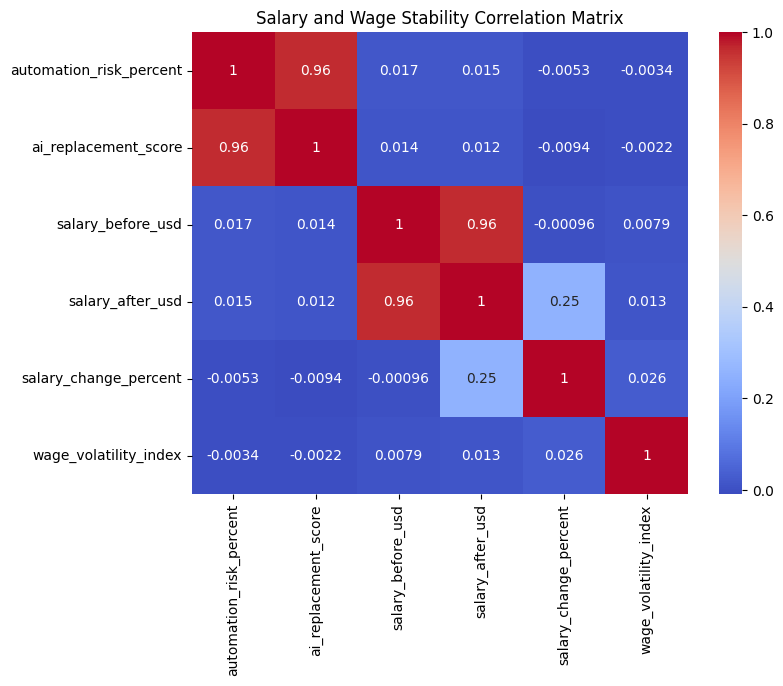

In [ ]:
salary_corr=df[['automation_risk_percent','ai_replacement_score','salary_before_usd','salary_after_usd','salary_change_percent','wage_volatility_index']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(salary_corr,annot=True,cmap='coolwarm')
plt.title('Salary and Wage Stability Correlation Matrix')
plt.show()

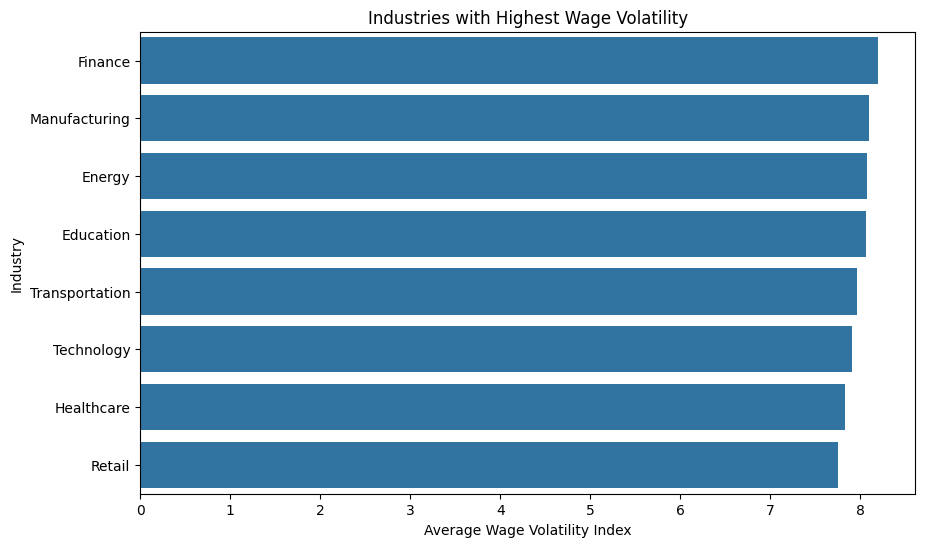

In [ ]:
industry_volatility = (df.groupby('industry')['wage_volatility_index'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(x=industry_volatility.values,y=industry_volatility.index)
plt.title('Industries with Highest Wage Volatility')
plt.xlabel('Average Wage Volatility Index')
plt.ylabel('Industry')
plt.show()

**OBJECTIVE 3**

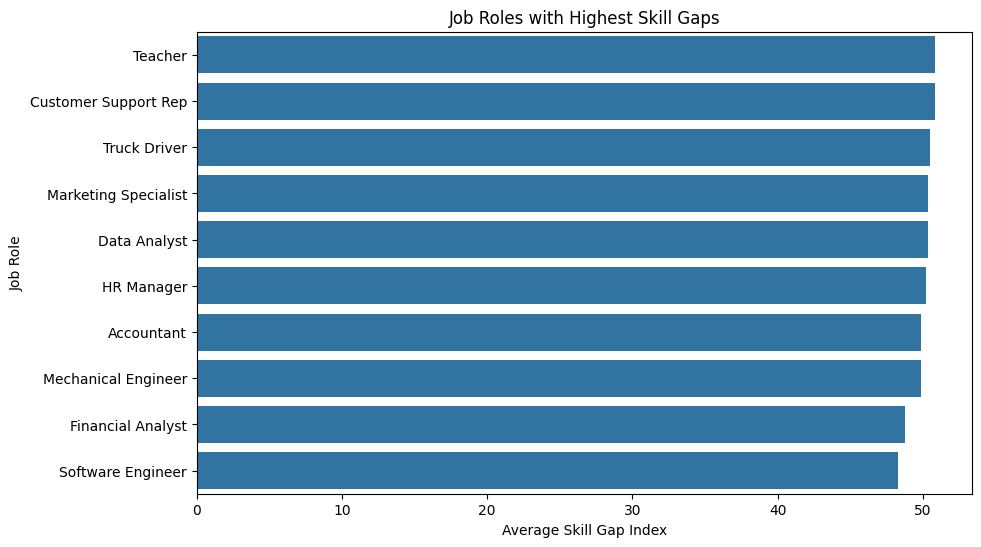

In [ ]:
job_skill_gap = (df.groupby('job_role')['skill_gap_index'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(x=job_skill_gap.values,y=job_skill_gap.index)
plt.title('Job Roles with Highest Skill Gaps')
plt.xlabel('Average Skill Gap Index')
plt.ylabel('Job Role')
plt.show()

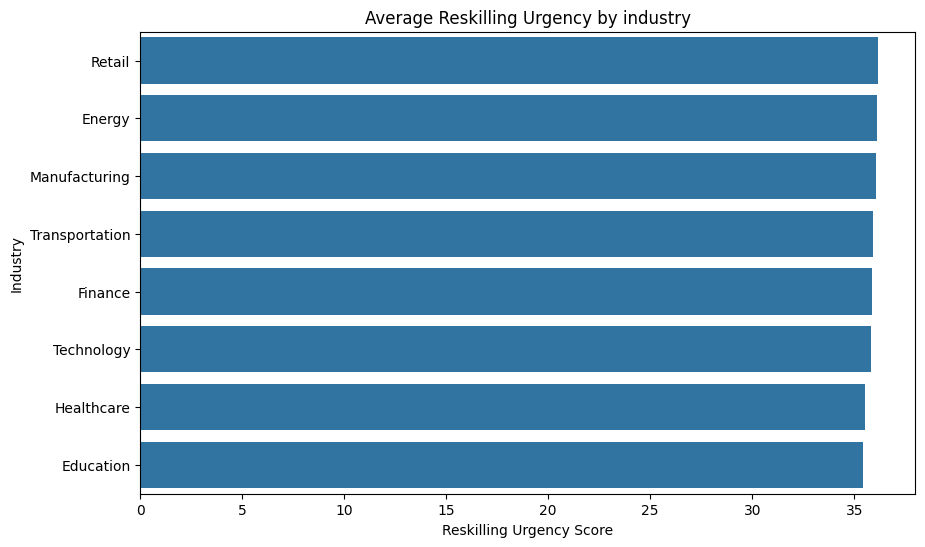

In [ ]:
industry_reskill = (df.groupby('industry')['reskilling_urgency_score'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(x=industry_reskill.values,y=industry_reskill.index)
plt.title('Average Reskilling Urgency by industry')
plt.xlabel('Reskilling Urgency Score')
plt.ylabel('Industry')
plt.show()

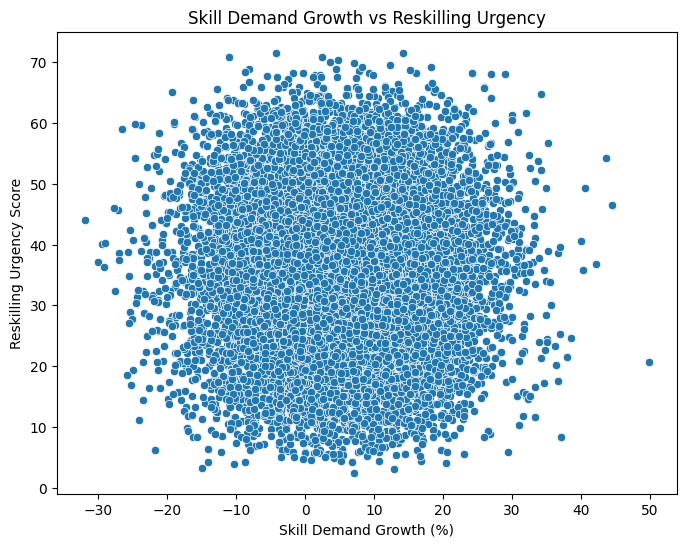

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='skill_demand_growth_percent', y='reskilling_urgency_score')
plt.title('Skill Demand Growth vs Reskilling Urgency')
plt.xlabel('Skill Demand Growth (%)')
plt.ylabel('Reskilling Urgency Score')
plt.show()

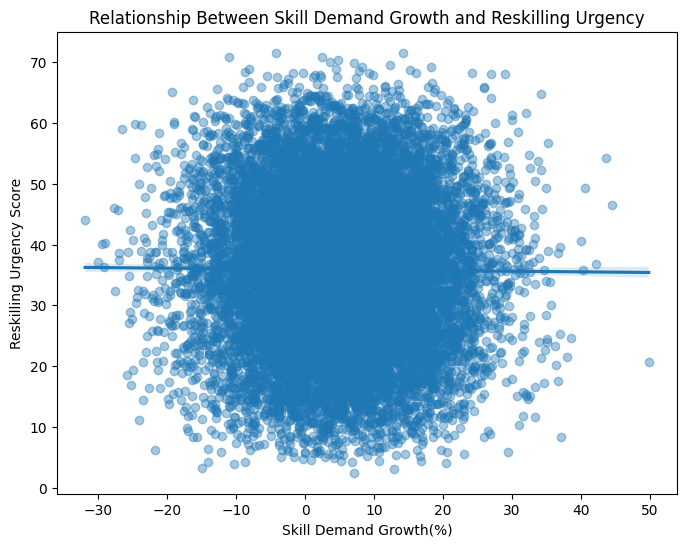

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,x='skill_demand_growth_percent', y='reskilling_urgency_score',scatter_kws={'alpha':0.4})
plt.title('Relationship Between Skill Demand Growth and Reskilling Urgency')
plt.xlabel('Skill Demand Growth(%)')
plt.ylabel('Reskilling Urgency Score')
plt.show()

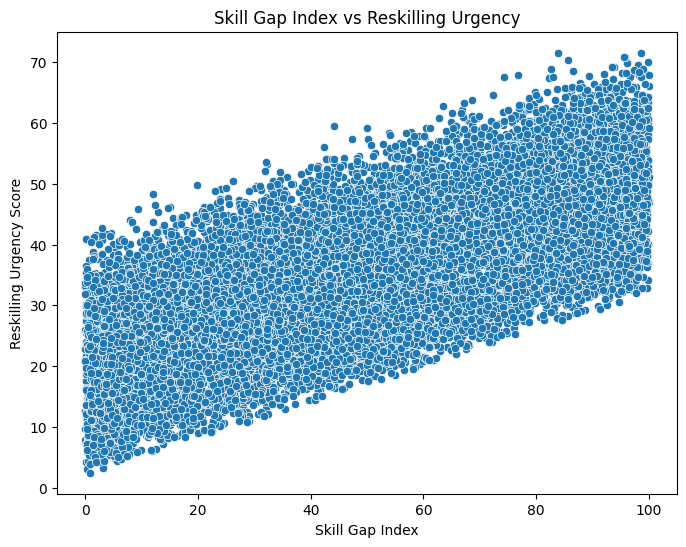

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='skill_gap_index', y='reskilling_urgency_score')
plt.title('Skill Gap Index vs Reskilling Urgency')
plt.xlabel('Skill Gap Index')
plt.ylabel('Reskilling Urgency Score')
plt.show()

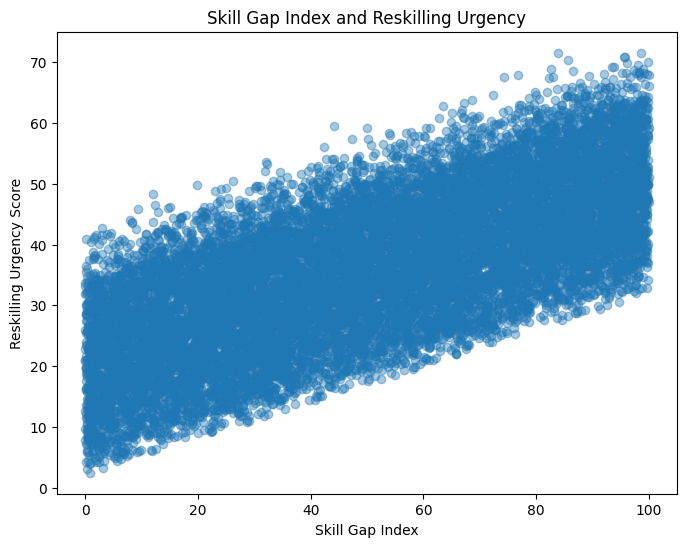

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='skill_gap_index', y='reskilling_urgency_score', scatter_kws={'alpha':0.4})
plt.title('Skill Gap Index and Reskilling Urgency')
plt.xlabel('Skill Gap Index')
plt.ylabel('Reskilling Urgency Score')
plt.show()

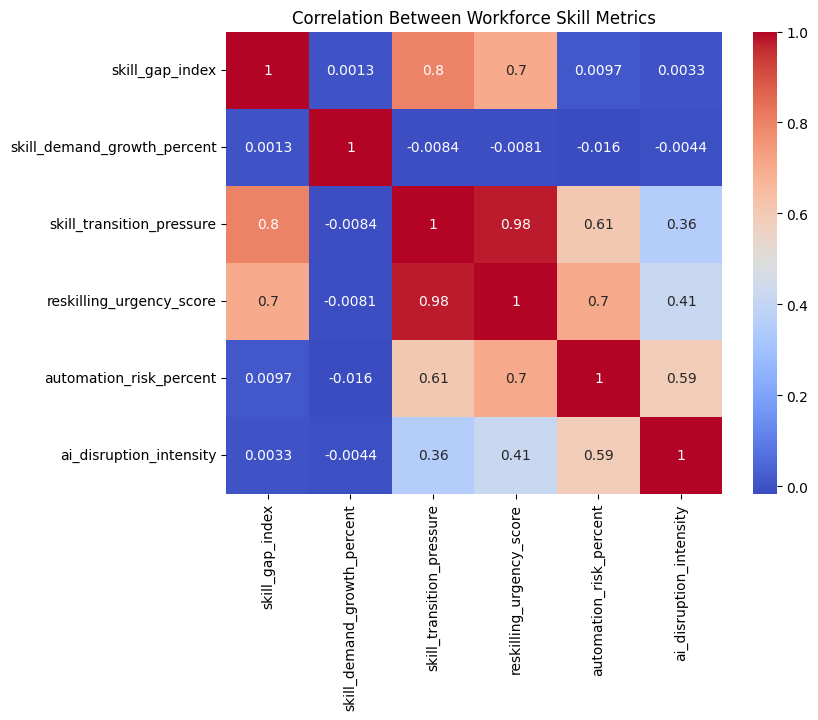

In [ ]:
skill_metrics=df[['skill_gap_index', 'skill_demand_growth_percent','skill_transition_pressure', 'reskilling_urgency_score', 'automation_risk_percent','ai_disruption_intensity' ]]
plt.figure(figsize=(8,6))
sns.heatmap(skill_metrics.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Between Workforce Skill Metrics')
plt.show()

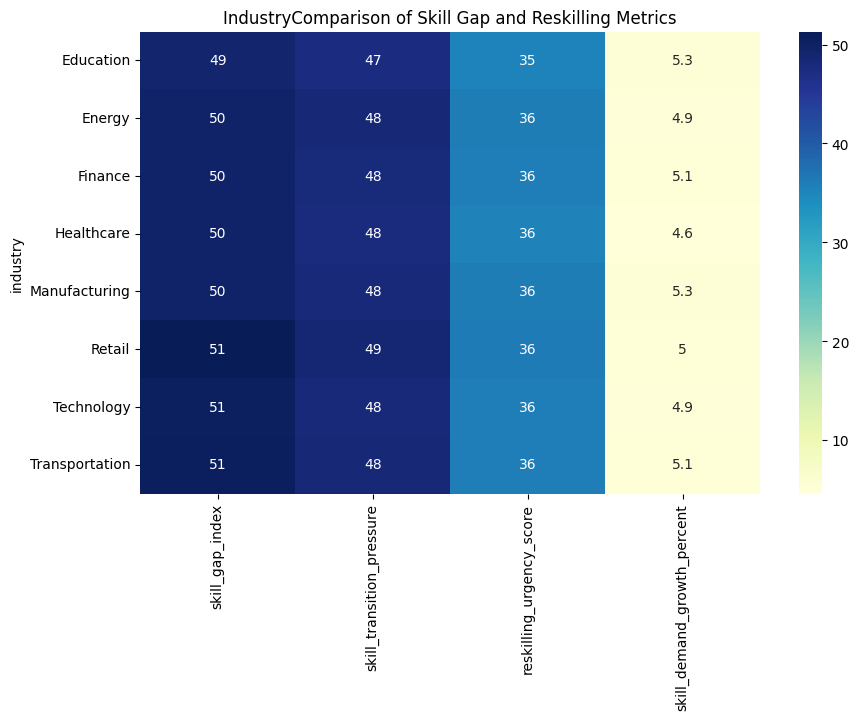

In [ ]:
industry_skills=df.groupby('industry')[['skill_gap_index','skill_transition_pressure','reskilling_urgency_score','skill_demand_growth_percent']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(industry_skills,annot=True,cmap='YlGnBu')
plt.title('IndustryComparison of Skill Gap and Reskilling Metrics')
plt.show()

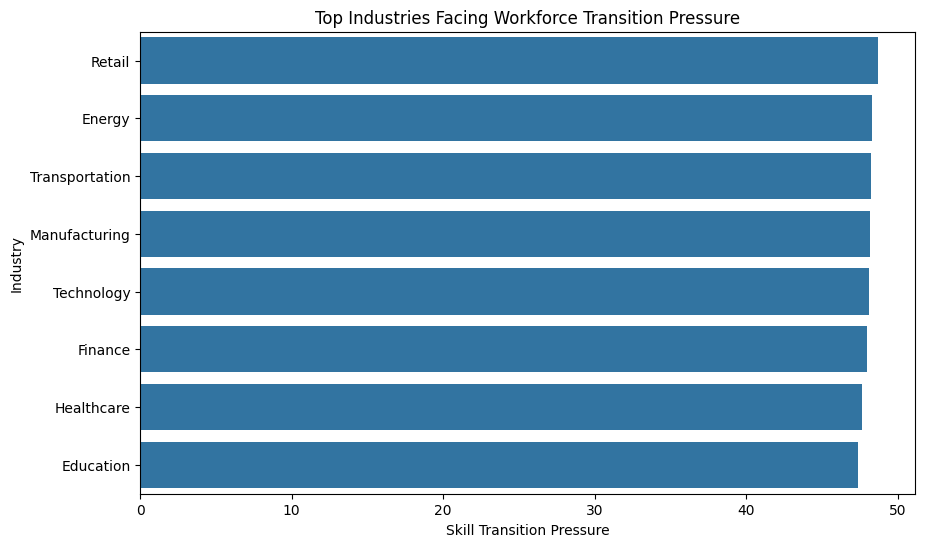

In [ ]:
top_transition=(df.groupby('industry')['skill_transition_pressure'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,6))
sns.barplot(x=top_transition.values, y=top_transition.index)
plt.title('Top Industries Facing Workforce Transition Pressure')
plt.xlabel('Skill Transition Pressure')
plt.ylabel('Industry')
plt.show()

**OBJECTIVE 4**

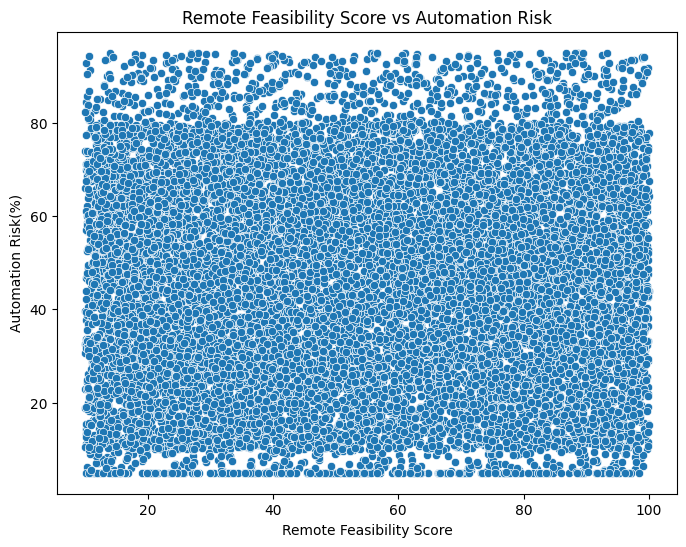

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='remote_feasibility_score',y='automation_risk_percent')
plt.title('Remote Feasibility Score vs Automation Risk')
plt.xlabel('Remote Feasibility Score')
plt.ylabel('Automation Risk(%)')
plt.show()

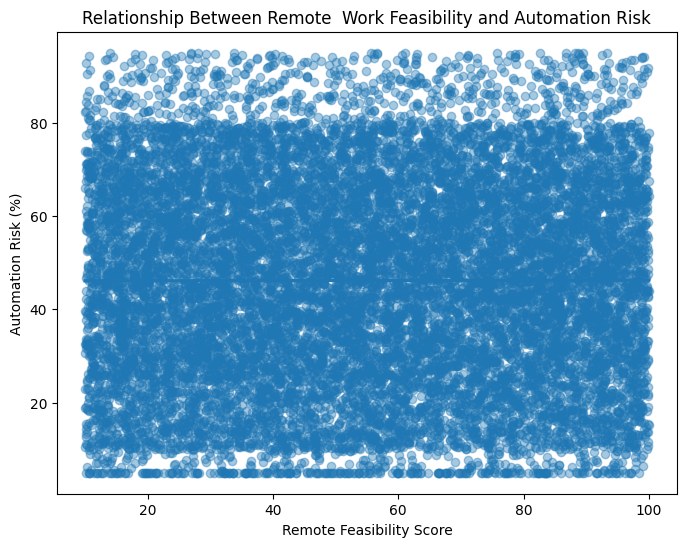

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df,x='remote_feasibility_score',y='automation_risk_percent',scatter_kws={'alpha':0.4})
plt.title('Relationship Between Remote  Work Feasibility and Automation Risk')
plt.xlabel('Remote Feasibility Score')
plt.ylabel('Automation Risk (%)')
plt.show()

In [ ]:
df[['remote_feasibility_score', 'automation_risk_percent']].corr()

,remote_feasibility_score,automation_risk_percent
remote_feasibility_score,1.000000,0.001511
automation_risk_percent,0.001511,1.000000


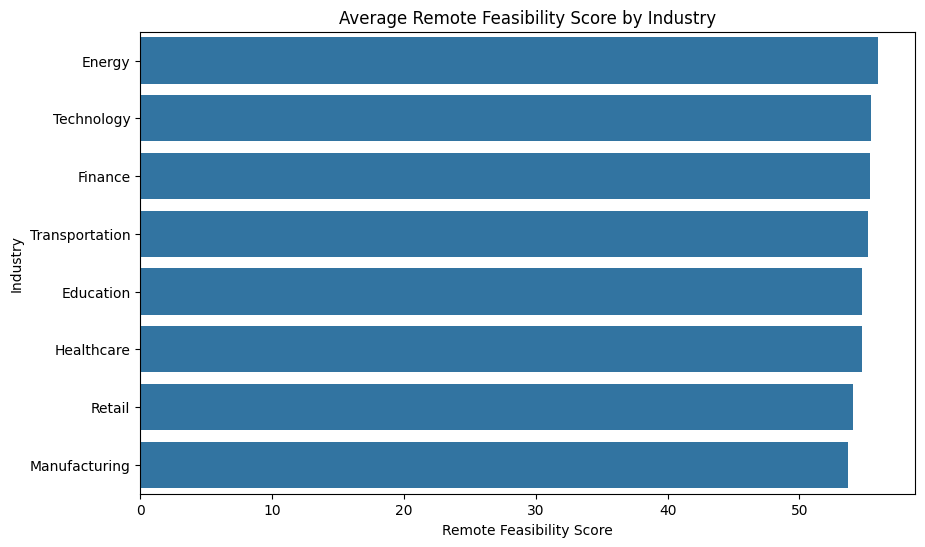

In [ ]:
industry_remote = (df.groupby('industry')['remote_feasibility_score'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(x=industry_remote.values,y=industry_remote.index)
plt.title('Average Remote Feasibility Score by Industry')
plt.xlabel('Remote Feasibility Score')
plt.ylabel('Industry')
plt.show()

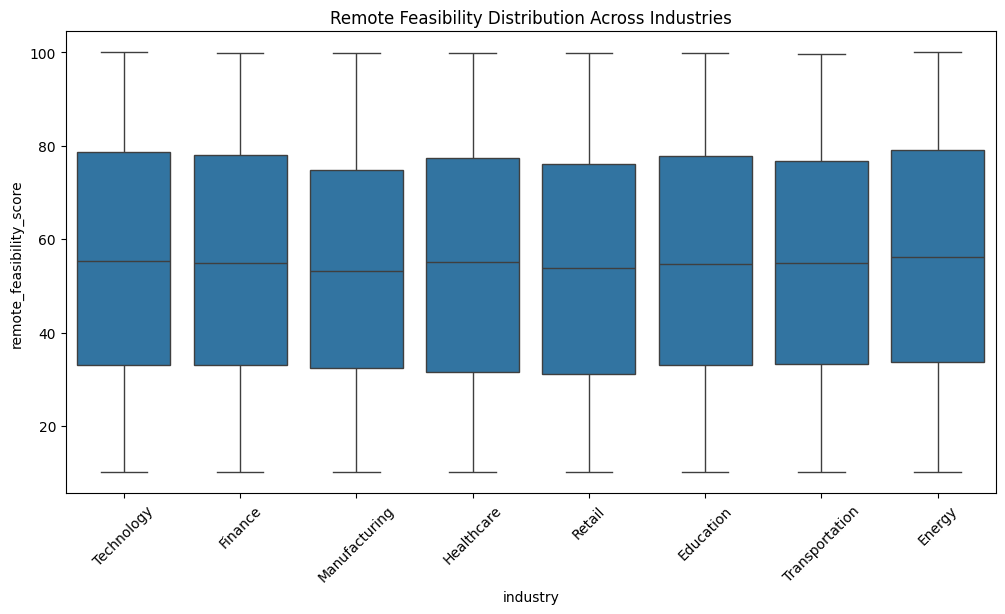

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='industry',y='remote_feasibility_score')
plt.title('Remote Feasibility Distribution Across Industries')
plt.xticks(rotation=45)
plt.show()

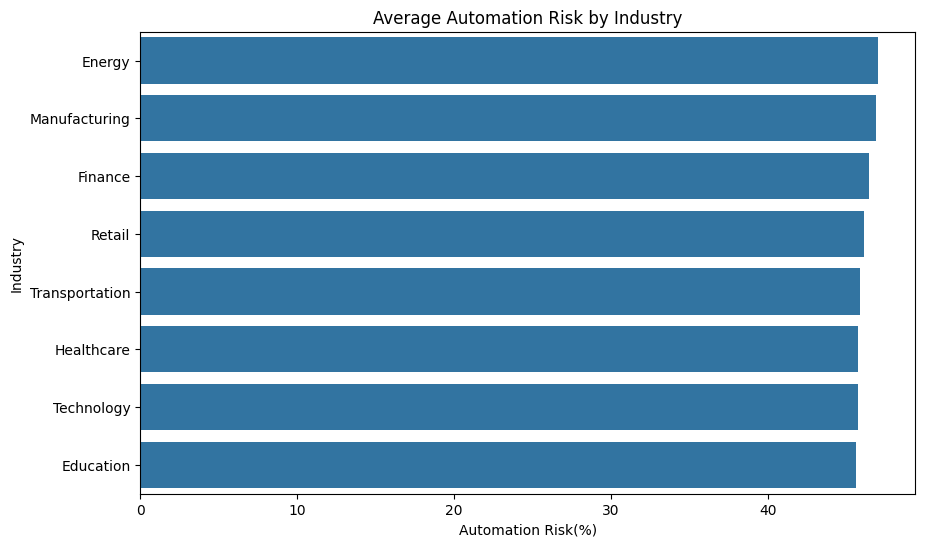

In [ ]:
industry_auto = (df.groupby('industry')['automation_risk_percent'] .mean() .sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(x=industry_auto.values,y=industry_auto.index)
plt.title('Average Automation Risk by Industry')
plt.xlabel('Automation Risk(%)')
plt.ylabel('Industry')
plt.show()

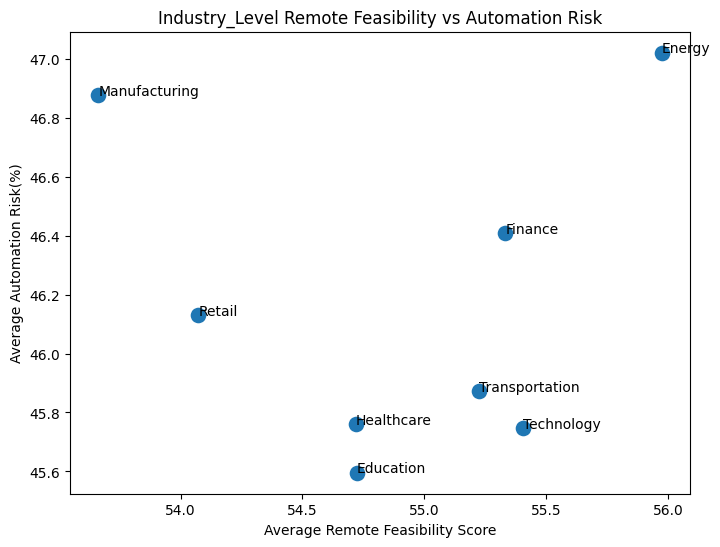

In [ ]:
industry_summary = (df.groupby('industry')[['remote_feasibility_score','automation_risk_percent']].mean())
plt.figure(figsize=(8,6))
sns.scatterplot(data=industry_summary, x='remote_feasibility_score',y='automation_risk_percent',s=150)
for industry in industry_summary.index: plt.text(industry_summary.loc[industry,'remote_feasibility_score'],industry_summary.loc[industry,'automation_risk_percent'],industry)
plt.title('Industry_Level Remote Feasibility vs Automation Risk')
plt.xlabel('Average Remote Feasibility Score')
plt.ylabel('Average Automation Risk(%)')
plt.show()

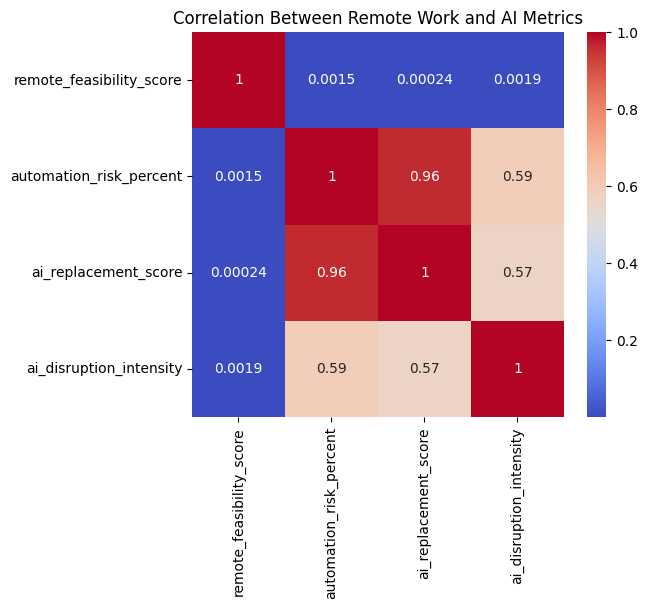

In [ ]:
remote_metrics = df[['remote_feasibility_score','automation_risk_percent','ai_replacement_score','ai_disruption_intensity']]
plt.figure(figsize=(6,5))
sns.heatmap(remote_metrics.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Between Remote Work and AI Metrics')
plt.show()

OBJECTIVE 5

In [ ]:
adoption_map= {'Low':1, 'Medium':2, 'High':3}
df['ai_adoption_numeric'] = df['ai_adoption_level'].map(adoption_map)

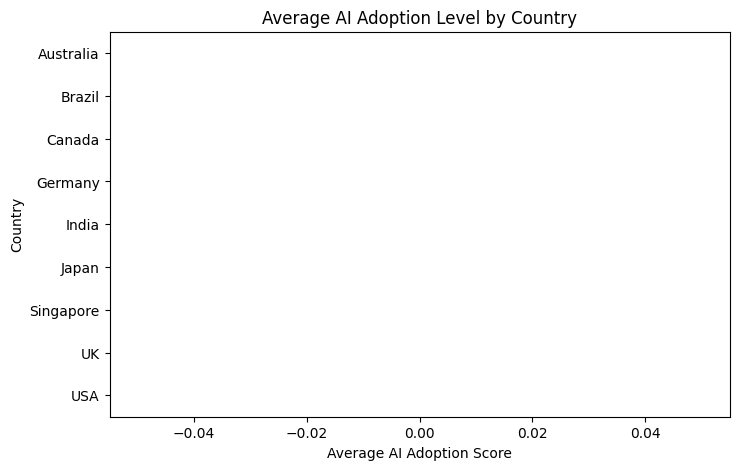

In [ ]:
country_adoption =(df.groupby('country')['ai_adoption_numeric'].mean().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=country_adoption.values,y=country_adoption.index)
plt.title('Average AI Adoption Level by Country')
plt.xlabel('Average AI Adoption Score')
plt.ylabel('Country')
plt.show()

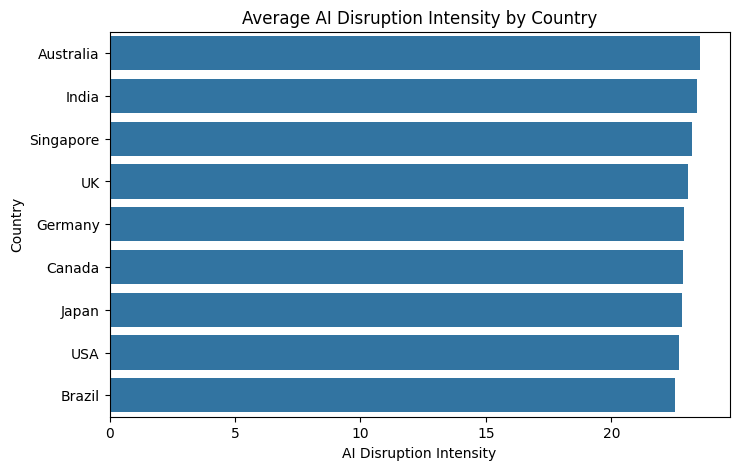

In [ ]:
country_disruption = (df.groupby('country')['ai_disruption_intensity'].mean().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=country_disruption.values, y=country_disruption.index)
plt.title('Average AI Disruption Intensity by Country')
plt.xlabel('AI Disruption Intensity')
plt.ylabel('Country')
plt.show()

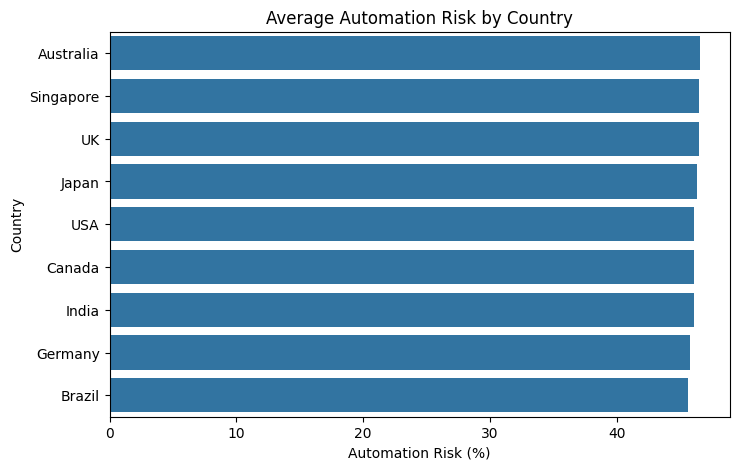

In [ ]:
country_risk = ( df.groupby ('country')['automation_risk_percent'].mean().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=country_risk.values, y=country_risk.index)
plt.title('Average Automation Risk by Country')
plt.xlabel('Automation Risk (%)')
plt.ylabel('Country')
plt.show()

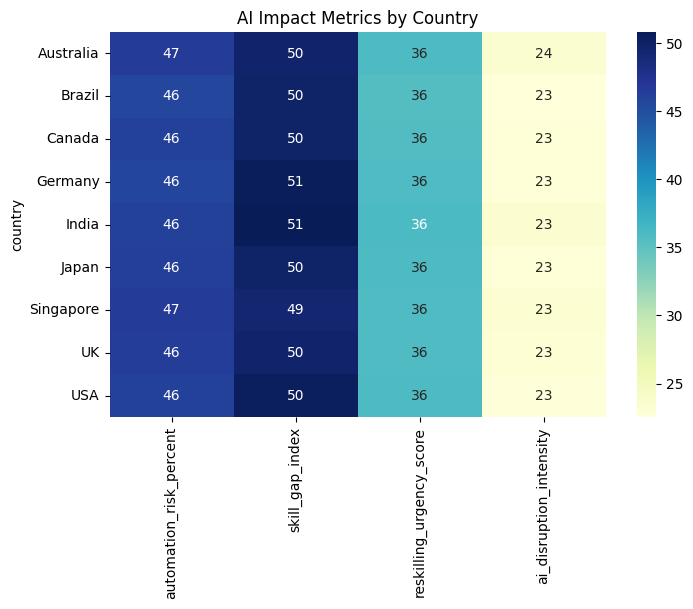

In [ ]:
country_metrics = df.groupby('country')[['automation_risk_percent','skill_gap_index','reskilling_urgency_score','ai_disruption_intensity']].mean()
plt.figure(figsize=(8,5))
sns.heatmap(country_metrics, annot=True, cmap='YlGnBu')
plt.title('AI Impact Metrics by Country')
plt.show()

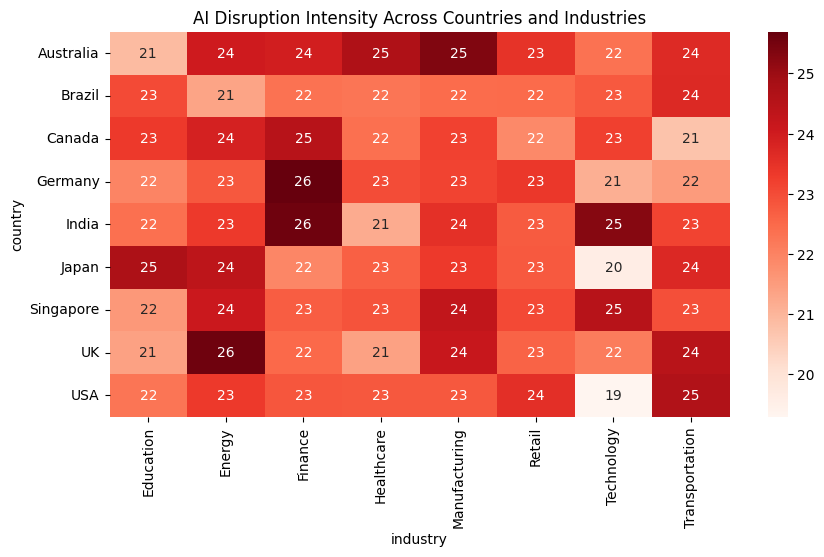

In [ ]:
country_industry = pd.pivot_table(df,values='ai_disruption_intensity',index='country', columns='industry', aggfunc='mean')
plt.figure(figsize=(10,5))
sns.heatmap(country_industry,cmap='Reds',annot=True)
plt.title('AI Disruption Intensity Across Countries and Industries')
plt.show()

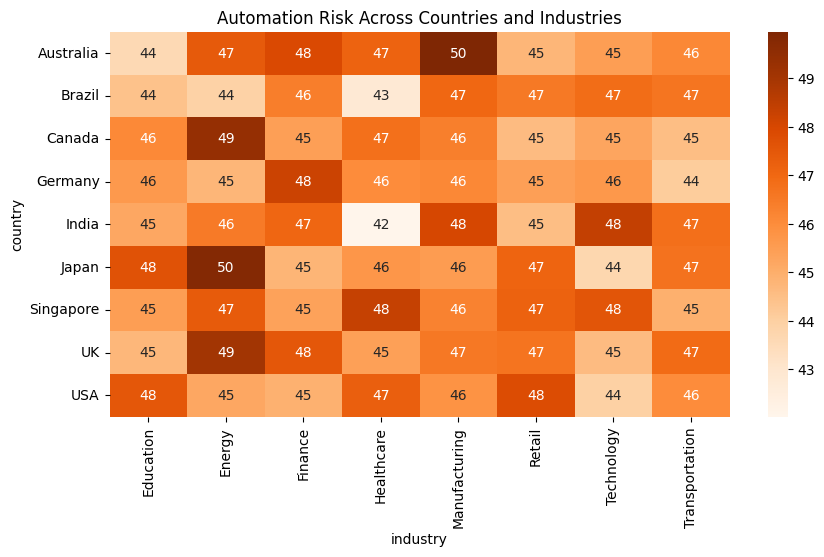

In [ ]:
risk_heatmap = pd.pivot_table(df, values= 'automation_risk_percent', index='country', columns='industry', aggfunc='mean')
plt.figure(figsize=(10,5))
sns.heatmap(risk_heatmap,cmap='Oranges',annot=True)
plt.title('Automation Risk Across Countries and Industries')
plt.show()

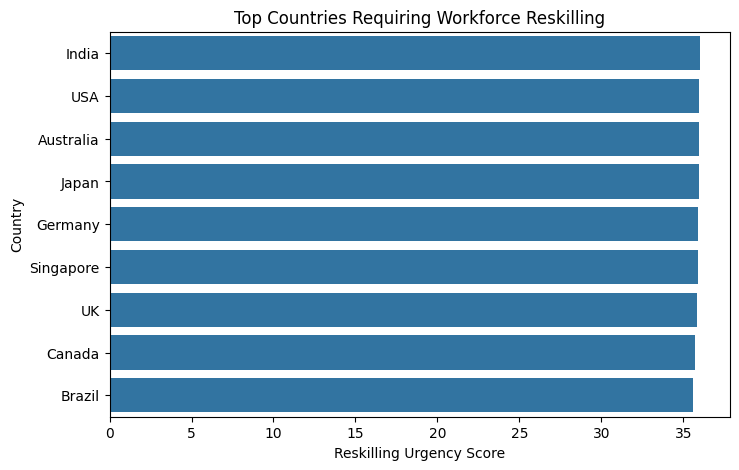

In [ ]:
country_reskill = (df.groupby('country')['reskilling_urgency_score'].mean().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=country_reskill.values, y=country_reskill.index)
plt.title('Top Countries Requiring Workforce Reskilling')
plt.xlabel('Reskilling Urgency Score')
plt.ylabel('Country')
plt.show()

ML Models

Time series analysis

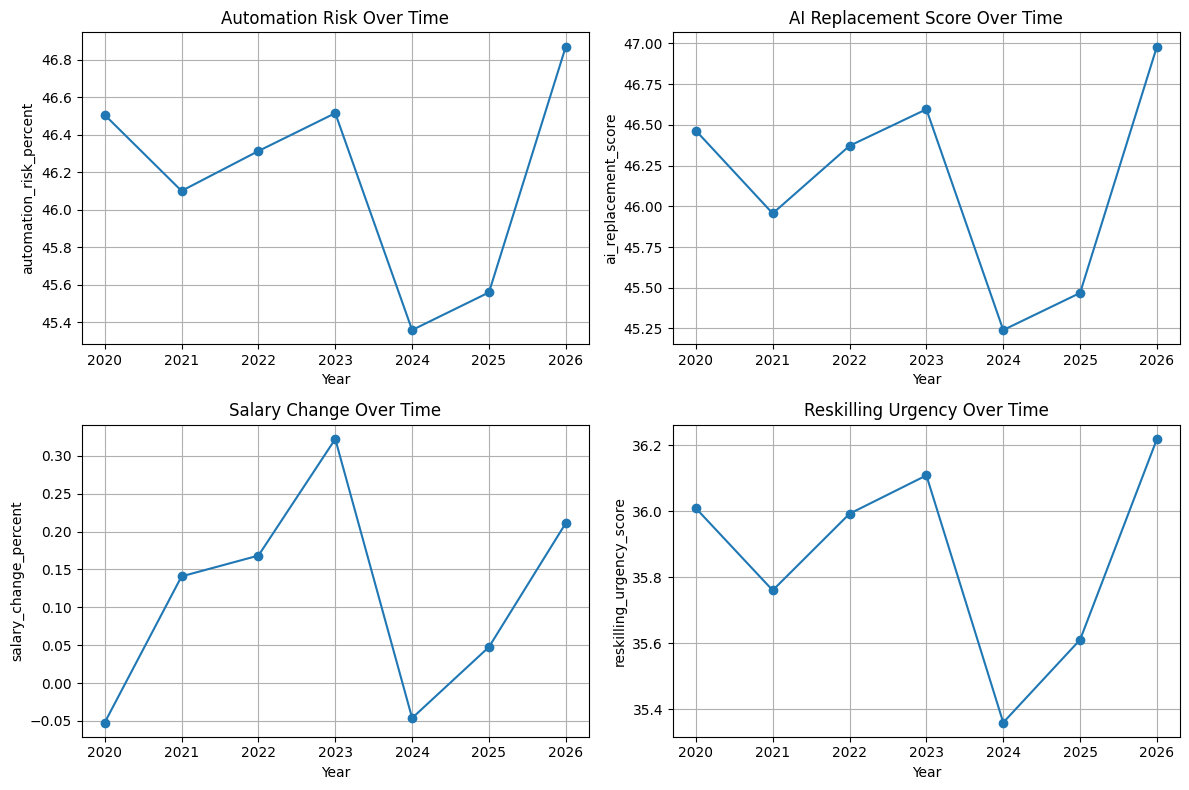

In [ ]:
#Average values by year
yearly_trends= df.groupby('year')[['automation_risk_percent','ai_replacement_score','salary_change_percent','reskilling_urgency_score']].mean().reset_index()

#Variables and titles
Variables =['automation_risk_percent','ai_replacement_score','salary_change_percent','reskilling_urgency_score']

titles =['Automation Risk Over Time','AI Replacement Score Over Time','Salary Change Over Time', 'Reskilling Urgency Over Time']

fig, axes = plt.subplots(2,2,figsize=(12,8))

for ax,var,title in zip(axes.flatten(), Variables, titles):
    ax.plot(yearly_trends['year'], yearly_trends[var],marker='o')
    ax.set_title (title)
    ax.set_xlabel('Year')
    ax.set_ylabel(var)
    ax.grid(True)

plt.tight_layout()
plt.show()




Predict Automation Risk (Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df[['ai_replacement_score','skill_gap_index','skill_demand_growth_percent','remote_feasibility_score','wage_volatility_index','reskilling_urgency_score','ai_disruption_intensity']]
y = df['automation_risk_percent']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test,pred))

R2 Score: 0.9845807400646446


Predict Automation risk (classification)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['ai_replacement_score','skill_gap_index','remote_feasibility_score','reskilling_urgency_score','ai_disruption_intensity']]
y = df['automation_risk_category']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))


Accuracy: 0.915


In [ ]:
print("="*70)
print("EXECUTIVE SUMMARY: AIJOB REPLACEMENT ANALYSIS")
print("="*70)

print(f"Average Automation Risk (2020): {df[df['year']==2020]['automation_risk_percent'].mean():.2f}%")
print(f"Average Automation Risk (2026): {df[df['year']==2026]['automation_risk_percent'].mean():.2f}%")

print(f"\nAverage Salary Change: {df['salary_change_percent'].mean():.2f}%")

print(f"High Risk Jobs: {(df['automation_risk_category']=='High').mean()*100:.2f}%")

print(f"Average Reskilling Urgency Score:{df['reskilling_urgency_score'].mean():.2f}")

print("\nCountry with Highest Automation Risk:")
print(df.groupby('country')['automation_risk_percent'].mean().idxmax())

print("\nCountry with Lowest Automation Risk:")
print(df.groupby('country')['automation_risk_percent'].mean().idxmax())

print("\nIndustry with Highest Automation Risk:")
print(df.groupby('industry')['automation_risk_percent'].mean().idxmax())

print("\nIndustry with Lowest Automation Risk:")
print(df.groupby('industry')['automation_risk_percent'].mean().idxmin())

print("\nTop 5 Job Roles by Automation Risk:")
print(df.groupby('job_role')['automation_risk_percent'].mean().sort_values(ascending=False).head())

print("="*70)


EXECUTIVE SUMMARY: AIJOB REPLACEMENT ANALYSIS
Average Automation Risk (2020): 46.50%
Average Automation Risk (2026): 46.87%

Average Salary Change: 0.11%
High Risk Jobs: 29.97%
Average Reskilling Urgency Score:35.87

Country with Highest Automation Risk:
Australia

Country with Lowest Automation Risk:
Australia

Industry with Highest Automation Risk:
Energy

Industry with Lowest Automation Risk:
Education

Top 5 Job Roles by Automation Risk:
job_role
Truck Driver            60.740895
Customer Support Rep    59.851052
Marketing Specialist    45.438711
Mechanical Engineer     45.397903
Teacher                 45.137897
Name: automation_risk_percent, dtype: float64
